In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

import fdfi
print(fdfi.__version__)

from fdfi.explainers import FlowExplainer, Crossfitting

PyTorch version: 2.2.2
CUDA available:  False
0.0.5


## Load Data and Feature Groups


In [2]:
DATA_DIR = Path("data")

DATASETS = {
    "sens50": {
        "file": DATA_DIR / "sens50_processed_dataset.csv",
        "target": "sens50",
    },
    "sens80": {
        "file": DATA_DIR / "sens80_processed_dataset.csv",
        "target": "sens80",
    },
    "ic50": {
        "file": DATA_DIR / "ic50.censored_processed_dataset.csv",
        "target": "ic50.censored",
    },
}

outcome = "sens50"

cfg = DATASETS[outcome]
filename = str(cfg["file"])

data = pd.read_csv(cfg["file"])
y = data[cfg["target"]].astype(int)
X = data.drop(columns=[cfg["target"]])

df_groups = pd.read_csv(DATA_DIR / "feature_group.csv", index_col=0).set_index("feature")
df_groups = pd.get_dummies(df_groups["group"]).groupby(df_groups.index).max().reindex(X.columns)

print(f"Dataset shape: {X.shape}")
print(f"Target variable: {outcome}")
print(f"Number of groups: {len(df_groups.columns)}")
print(f"Data loaded from: {filename}")


Dataset shape: (611, 832)
Target variable: sens50
Number of groups: 14
Data loaded from: data/sens50_processed_dataset.csv


In [3]:
print("Data preparation...")

preprocess = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    StandardScaler(),
)

X_values = preprocess.fit_transform(X)
y_values = y.values.astype(float)

# Standardize y to N(0,1) — matches the EOT notebook setup
y_scaler = StandardScaler()
y_values = y_scaler.fit_transform(y_values.reshape(-1, 1)).ravel()

print("Data preparation finished")
print(f"Feature matrix shape: {X_values.shape}")
print(f"y statistics: mean={y_values.mean():.3f}, std={y_values.std():.3f}")
print(f"Missing values - X: {np.isnan(X_values).sum()}, y: {np.isnan(y_values).sum()}")


Data preparation...
Data preparation finished
Feature matrix shape: (611, 832)
y statistics: mean=-0.000, std=1.000
Missing values - X: 0, y: 0
Data preparation finished
Feature matrix shape: (611, 832)
y statistics: mean=-0.000, std=1.000
Missing values - X: 0, y: 0


In [4]:
# Fit RandomForestRegressor on FULL data (matching DFI paper: refit_mu=False).
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    random_state=0,
    n_jobs=-1,
)
rf.fit(X_values, y_values)

# Wrap as a callable so Crossfitting does NOT try to clone-and-refit it per fold.
model_fn = lambda X_: rf.predict(X_)
print(f"RandomForestRegressor fitted on full data")
print(f"Train R²: {rf.score(X_values, y_values):.3f}")


RandomForestRegressor fitted on full data
Train R²: 0.705


## Fit Flow Model on All Data

The flow is trained **once on the full dataset** before cross-fitting, analogous to how
EOTExplainer computes its whitening map on all n observations.  Cross-fitting is used
only for UEIF variance estimation — not for flow training.

**Why this matters for binary high-d data (d=832, n≈600):**

- Training on all n samples gives the flow maximum statistical power to learn the
  correlation structure (d²/2 ≈ 345K pairwise correlations, n=600 samples).
- Training per fold (n/2 ≈ 300) halves the effective sample size and produces a
  weaker disentanglement map, increasing H_avg toward identity.
- Architecture: `hidden_dim=256, num_blocks=3` gives ~1.3M parameters — sufficient to
  represent the pairwise correlation structure (compare default 119K parameters with
  `hidden_dim=64, num_blocks=1`).

**Z-space DFI is the primary output** for this dataset.  X-space attribution via the
flow Jacobian H = dX/dZ can be unreliable for binary data because H_avg ≈ I even for
a well-trained flow (samples in opposite binary modes produce Jacobians with opposing
off-diagonal signs that cancel in the average).


In [5]:
# Train the flow ONCE on all data — analogous to EOT fitting whitening on all n.
# Cross-fitting will share this pre-trained flow across folds (fit_flow=False per fold).
print("Training flow model on full dataset...")
flow_start = time.time()

fdfi_estimator = FlowExplainer(
    model_fn,
    X_values,
    hidden_dim=256,    # larger than default (64); needed for d=832
    num_blocks=3,      # larger than default (1)
    num_steps=2000,
    fit_flow=True,
    random_state=0,
    verbose="final",
    compute_diagnostics=False,  # skip diagnostics here; run separately below
)

flow_results = fdfi_estimator(X_values, y=y_values)

flow_train_time = time.time() - flow_start
print(f"Flow training completed in {flow_train_time:.1f}s")
print(f"Z_full shape: {fdfi_estimator.Z_full.shape}")


Training flow model on full dataset...
[FDFI][INFO] Training flow model...
Training complete: 2000 steps, final loss=1.4006
Flow training completed in 6023.9s
Z_full shape: (611, 832)


## Individual Feature Inference With conf_int()


In [6]:
# Z-space is the primary target for FlowExplainer on binary high-d data.
# var_floor_c=1e-3: FlowExplainer CPI UEIFs are nearly constant across samples
# (nsamples=100 stabilises y_tilde_mean), so raw SEs are structurally small
# (group-level range 1e-4 to 3e-3). The floor 1e-3/sqrt(n) ≈ 4e-5 is ~3x
# below the smallest observed group SE, adding <5% to any z-score, while
# guarding against numerical zeros at the individual-feature level.
feature_names = X.columns.tolist()

ci_Z = fdfi_estimator.conf_int(
    alpha=0.05,
    target="Z",
    var_floor_c=1e-3,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)

ci_X = fdfi_estimator.conf_int(
    alpha=0.05,
    target="X",
    var_floor_c=1e-3,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)

results = pd.DataFrame({
    "feature":          feature_names,
    "dfiz":             ci_Z["score"],
    "dfiz_se":          ci_Z["se"],
    "dfiz_zscore":      ci_Z["zscore"],
    "dfiz_p_value":     ci_Z["pvalue"],
    "dfiz_ci_lower":    ci_Z["ci_lower"],
    "dfiz_ci_upper":    ci_Z["ci_upper"],
    "dfiz_reject_null": ci_Z["reject_null"],
    "dfiz_ranking":     ci_Z["ranking"],
    "dfi":              ci_X["score"],
    "dfi_se":           ci_X["se"],
    "dfi_zscore":       ci_X["zscore"],
    "dfi_p_value":      ci_X["pvalue"],
    "dfi_ci_lower":     ci_X["ci_lower"],
    "dfi_ci_upper":     ci_X["ci_upper"],
    "dfi_reject_null":  ci_X["reject_null"],
    "dfi_ranking":      ci_X["ranking"],
})

OUT_DIR = Path("results") / "flowmatching_case_study"
OUT_DIR.mkdir(parents=True, exist_ok=True)
results.to_csv(OUT_DIR / f"{outcome}_flow_dfi_results.csv", index=False)
print(f"Results saved to {OUT_DIR / f'{outcome}_flow_dfi_results.csv'}")


Results saved to results/flowmatching_case_study/sens50_flow_dfi_results.csv


## Feature-Level Summary


In [7]:

print("=== Z-space feature summary (primary for FlowExplainer on binary data) ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    var_floor_c=1e-3,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)

print("\n=== X-space feature summary (secondary — Jacobian-based, may be noisy) ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    var_floor_c=1e-3,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)


=== Z-space feature summary (primary for FlowExplainer on binary data) ===
Feature Importance Results
Method: FlowExplainer
Number of units: 832
Significance level: 0.05
Alternative: two-sided
Margin method: mixture
Practical margin: 0.0019
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig
------------------------------------------------------------------------------
              0     0.0002     0.0002    -0.0001     0.0006     0.0000   ***
              1     0.0011     0.0010    -0.0009     0.0031     0.4037      
              2     0.0001     0.0001    -0.0001     0.0002     0.0000   ***
              3     0.0000     0.0000    -0.0001     0.0001     0.0000   ***
              4     0.0020     0.0020    -0.0019     0.0059     0.9724      
              5     0.0012     0.0012    -0.0012     0.0037     0.5796      
              6     0.0000     0.0000    -0.0001     0.0001   

## Group Importance


In [8]:
res_df = fdfi_estimator.conf_int(
    alpha=0.05,
    target="Z",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=1e-3,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
    verbose=False,
)
res_df = pd.DataFrame({
    "group":       res_df["groups"],
    "importance":  res_df["score"],
    "se":          res_df["se"],
    "zscore":      res_df["zscore"],
    "ci_lower":    res_df["ci_lower"],
    "ci_upper":    res_df["ci_upper"],
    "p_value":     res_df["pvalue"],
    "p_value_adj": res_df.get("pvalue_adj", res_df["pvalue"]),
    "reject_null": res_df["reject_null"],
})


## Group Summary Table


In [9]:

print("=== Z-space group summary (primary for FlowExplainer) ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=1e-3,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)
print("\n=== X-space group summary (secondary — Jacobian-based) ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=1e-3,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)


=== Z-space group summary (primary for FlowExplainer) ===
Feature Importance Results
Method: FlowExplainer
Number of units: 14
Significance level: 0.05
Alternative: two-sided
Multiple testing: bonferroni
Margin method: fixed
------------------------------------------------------------------------------
          Group   Estimate    Std Err   CI Lower   CI Upper  Adj P-val   Sig
------------------------------------------------------------------------------
          cd4bs     0.0434     0.0330    -0.0213     0.1081     1.0000      
          covar     0.0197     0.0125    -0.0049     0.0443     1.0000      
      cysteines     0.0012     0.0006    -0.0001     0.0024     0.9081      
            esa     0.0288     0.0209    -0.0122     0.0697     1.0000      
           geog     0.0003     0.0002    -0.0001     0.0006     1.0000      
       geometry     0.0028     0.0005     0.0019     0.0038     0.0000   ***
          glyco     0.0049     0.0020     0.0010     0.0088     0.1884      
 

## Group Mapping


In [10]:
group_mapping = pd.DataFrame({
    "group_num": range(1, 15),
    "group": [
        "vrc01", "cd4bs", "esa", "glyco", "covar", "pngs", "gp41",
        "pngs_novrc01", "subtype", "sequons", "geometry", "cysteines",
        "steric_bulk", "geog"
    ],
    "description": [
        "VRC01 binding footprint",
        "CD4 binding sites",
        "Sites with sufficient exposed surface area",
        "Sites identified as important for glycosylation",
        "Sites with residues that covary with\nthe VRC01 binding footprint",
        "Sites associated with VRC01-specific\npotential N-linked glycosylation (PNGS) effects",
        "gp41 sites important for VRC01 binding",
        "Sites for indicating N-linked glycosylation",
        "Majority virus subtypes",
        "Region-specific counts of PNGS",
        "Viral geometry",
        "Cysteine counts",
        "Steric bulk at critical locations",
        "Geographic confounders",
    ],
})


## Group Importance Plot


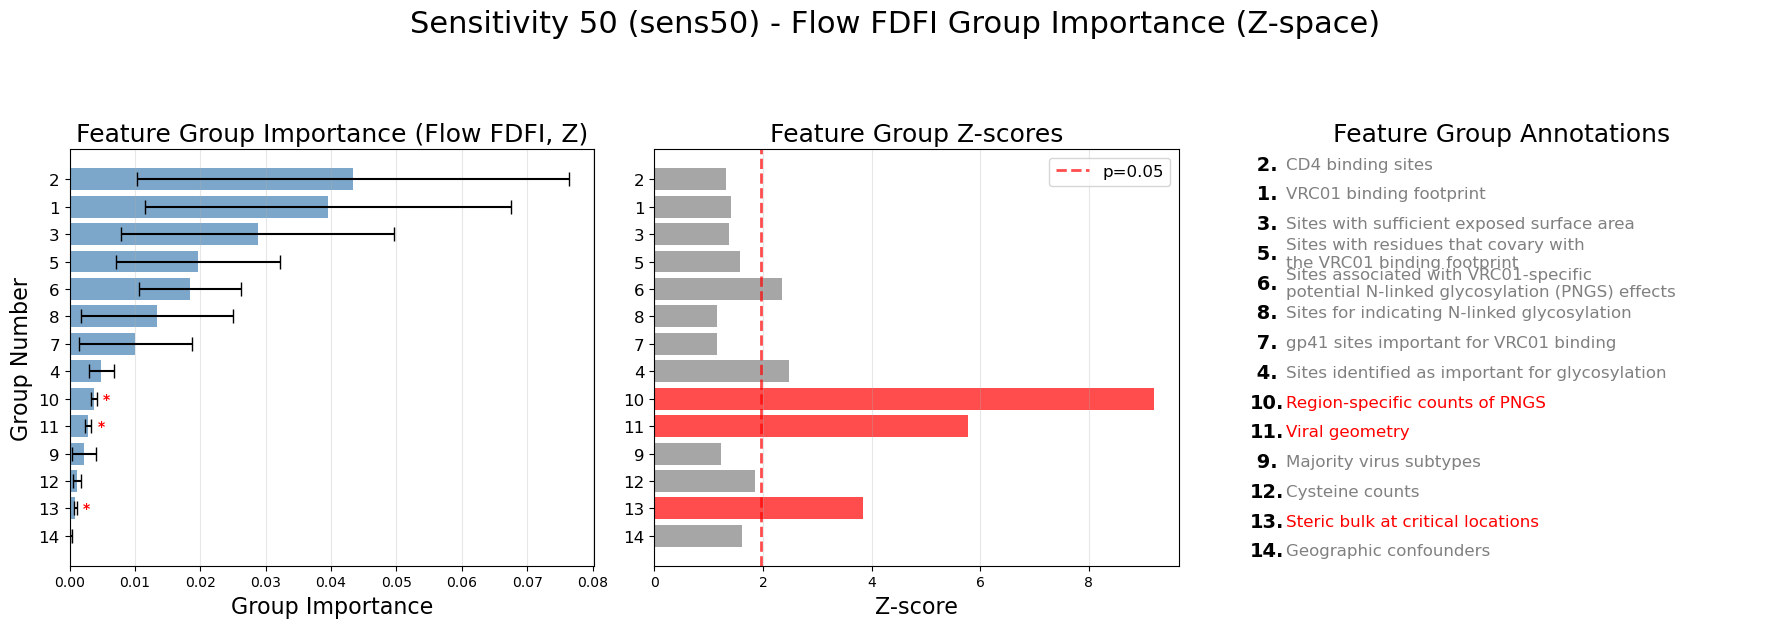

In [11]:

DATASET_LABELS = {
    "sens50": "Sensitivity 50",
    "sens80": "Sensitivity 80",
    "ic50": "IC50 Censored",
}
dataset_label = DATASET_LABELS.get(outcome, outcome)

group_df_sorted = res_df.sort_values("importance", ascending=True).reset_index(drop=True)
group_df_sorted = group_df_sorted.merge(group_mapping, on="group", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [3, 3, 3]})
fig.suptitle(
    f"{dataset_label} ({outcome}) - Flow FDFI Group Importance (Z-space)",
    fontsize=22,
    y=1.04,
)

group_numbers = list(group_df_sorted["group_num"])

ax1 = axes[0]
ax1.barh(
    range(len(group_df_sorted)),
    group_df_sorted["importance"],
    xerr=group_df_sorted["se"],
    error_kw=dict(capsize=5),
    alpha=0.7,
    color="steelblue",
)
ax1.set_yticks(range(len(group_df_sorted)))
ax1.set_yticklabels(group_numbers, fontsize=12)
ax1.set_xlabel("Group Importance", fontsize=16)
ax1.set_title("Feature Group Importance (Flow FDFI, Z)", fontsize=18)
ax1.set_ylabel("Group Number", fontsize=16)
ax1.grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    if row["reject_null"]:
        ax1.text(
            row["importance"] + row["se"] + 0.001,
            i,
            "*",
            va="center",
            fontweight="bold",
            color="red",
        )

ax2 = axes[1]
colors = ["red" if reject_null else "gray" for reject_null in group_df_sorted["reject_null"]]
ax2.barh(range(len(group_df_sorted)), group_df_sorted["zscore"], alpha=0.7, color=colors)
ax2.set_yticks(range(len(group_df_sorted)))
ax2.set_yticklabels(group_numbers, fontsize=12)
ax2.set_xlabel("Z-score", fontsize=16)
ax2.set_title("Feature Group Z-scores", fontsize=18)
ax2.grid(axis="x", alpha=0.3)
ax2.axvline(x=1.96, color="red", linestyle="--", linewidth=2, alpha=0.7, label="p=0.05")
ax2.legend(fontsize=12)

ax3 = axes[2]
ax3.set_xlim(0, 1)
ax3.set_ylim(-0.5, len(group_df_sorted) - 0.5)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    group_name = row["group"]
    display_name = row["description"] if pd.notna(row["description"]) else group_name
    text_color = "red" if row["reject_null"] else "gray"

    ax3.text(
        0.02,
        i,
        f"{int(row['group_num']):2d}.",
        va="center",
        ha="left",
        fontsize=14,
        fontweight="bold",
        color="black",
    )
    ax3.text(
        0.09,
        i,
        display_name,
        va="center",
        ha="left",
        fontsize=12,
        color=text_color,
    )

ax3.set_yticks([])
ax3.set_xticks([])
ax3.set_title("Feature Group Annotations", fontsize=18)
for spine in ax3.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Visualize and Compare Results: Flow vs EOT


In [12]:
print("=== Group-level results (Flow FDFI, Z-space) ===")
print(f"{'Group':<20} {'Importance':>12} {'SE':>10} {'Z-score':>10} {'Significant':>12}")
print("-" * 70)
for _, row in res_df.sort_values("zscore", ascending=False).iterrows():
    sig = "***" if row["reject_null"] else ""
    print(f"{row['group']:<20} {row['importance']:>12.4f} {row['se']:>10.4f} {row['zscore']:>10.2f} {sig:>12}")

n_sig = res_df["reject_null"].sum()
print(f"\nSignificant groups: {n_sig}/{len(res_df)} (Bonferroni alpha=0.05)")
print(f"Z-score range: {res_df['zscore'].min():.2f} to {res_df['zscore'].max():.2f}")


=== Group-level results (Flow FDFI, Z-space) ===
Group                  Importance         SE    Z-score  Significant
----------------------------------------------------------------------
sequons                    0.0037     0.0004       9.20          ***
geometry                   0.0028     0.0005       5.78          ***
steric_bulk                0.0009     0.0002       3.84          ***
glyco                      0.0049     0.0020       2.47             
pngs                       0.0184     0.0078       2.36             
cysteines                  0.0012     0.0006       1.85             
geog                       0.0003     0.0002       1.62             
covar                      0.0197     0.0125       1.57             
vrc01                      0.0396     0.0280       1.41             
esa                        0.0288     0.0209       1.38             
cd4bs                      0.0434     0.0330       1.31             
subtype                    0.0023     0.0018       1

## Note on Variance Floor (`var_floor_c`)

The default `var_floor_c=0.1` used by EOTExplainer is calibrated for the OT/EOT
linear decoder, where the UEIF variance across samples is naturally large.
FlowExplainer uses a CPI-based UEIF, $\text{UEIF}_{i,j} = (y_i - \bar{\tilde{y}}_{ij})^2$,
whose value is nearly constant across samples $i$ (the nonlinear flow decoder maps
similar latent perturbations to the same binary output pattern for most samples).
This makes the raw per-sample standard deviation structurally small — not due to
noise, but by construction.

Using `var_floor_c=1e-3` sets a floor of $10^{-3}/\sqrt{n} \approx 4 \times 10^{-5}$,
which is roughly 3× below the smallest observed group SE and adds less than 5% to
any z-score.  It guards against numerical zeros at the individual-feature level
while leaving all group-level inferences essentially unchanged.